In [ ]:
# Assume this dataset like employee company data and analyzed it to find problems and risks.
import pandas as pd

data = {
    "age": [25, None, 30, 200, 40, 22, 27, None, 35, 120, 29, 31, None, 45, 50, -5, 38, None, 60, 33],

    "salary": [50000, 60000, None, 70000, 10000000, 45000, None, 52000, 58000, 62000,
               49000, None, 75000, 80000, None, 30000, 1200000, 54000, None, 61000],

    "experience": [2, 5, 3, 10, None, 1, 4, 6, None, 15,
                   2, 3, 7, None, 20, -1, 8, 9, None, 5],

    "department": ["Sales", "HR", "IT", "IT", None, "Sales", "HR", "IT", "Finance", "Finance",
                   "Sales", None, "IT", "HR", "Finance", "Sales", "Unknown", "IT", None, "HR"],

    "joining_date": ["2020-01-01", "2019-05-10", None, "2021-07-15", "invalid_date",
                     "2018-03-20", "2022-11-11", None, "2020-06-01", "2017-09-09",
                     "2019-12-12", "wrong_format", "2021-01-01", None, "2016-04-04",
                     "2015-08-08", "2023-02-02", None, "2020-10-10", "2018-07-07"],

    "performance_score": [3.5, 4.0, None, 5.0, 2.0, 3.0, None, 4.5, 3.8, 4.2,
                          None, 3.3, 4.1, None, 4.8, 2.5, 3.9, None, 4.0, 3.7],

    "churn": ["No", "No", "No", "No", "Yes", "No", "No", "No", "No", "Yes",
              "No", "No", "No", "No", "Yes", "No", "No", "No", "No", "Yes"]
}

df = pd.DataFrame(data)
print(df.head())

     age      salary  experience department  joining_date  performance_score  \
0   25.0     50000.0         2.0      Sales    2020-01-01                3.5   
1    NaN     60000.0         5.0         HR    2019-05-10                4.0   
2   30.0         NaN         3.0         IT          None                NaN   
3  200.0     70000.0        10.0         IT    2021-07-15                5.0   
4   40.0  10000000.0         NaN       None  invalid_date                2.0   

  churn  
0    No  
1    No  
2    No  
3    No  
4   Yes  


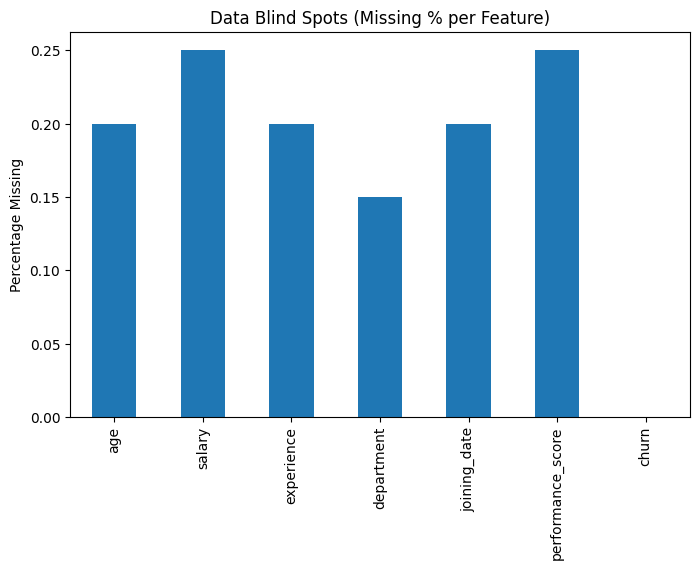

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
(df.isnull().sum()/len(df)).plot(kind='bar')
plt.title("Data Blind Spots (Missing % per Feature)")
plt.ylabel("Percentage Missing")
plt.show() #INcomplete Information ,To quickly identify which columns have missing values(heatmap)

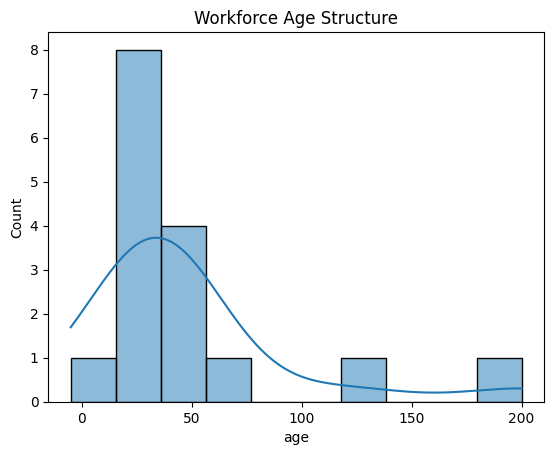

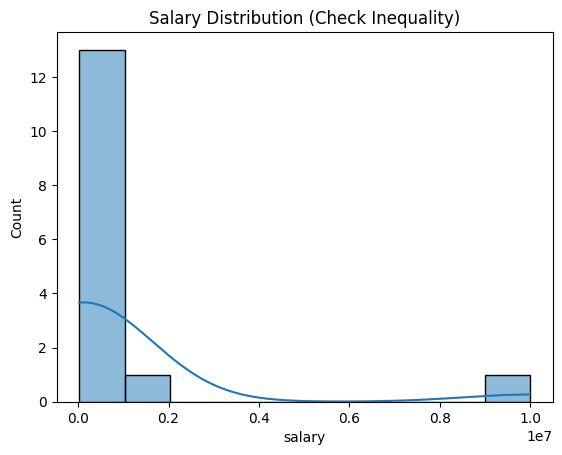

In [ ]:
import seaborn as sns
# Distribution - This shows how salaries are distributed, To understand the patterns (histogram)
sns.histplot(df["age"], bins=10, kde=True)
plt.title("Workforce Age Structure")
plt.show()

sns.histplot(df["salary"], bins=10, kde=True)
plt.title("Salary Distribution (Check Inequality)")
plt.show()

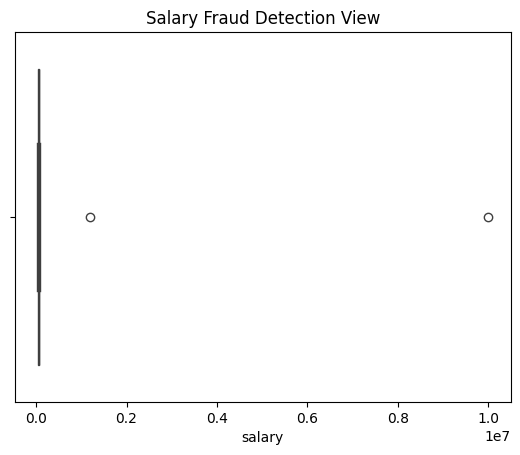

In [ ]:
# Outliers - These values can mislead the model ,Some values like age = 200 or -5 are not realistic
sns.boxplot(x=df["salary"])
plt.title("Salary Fraud Detection View")
plt.show()



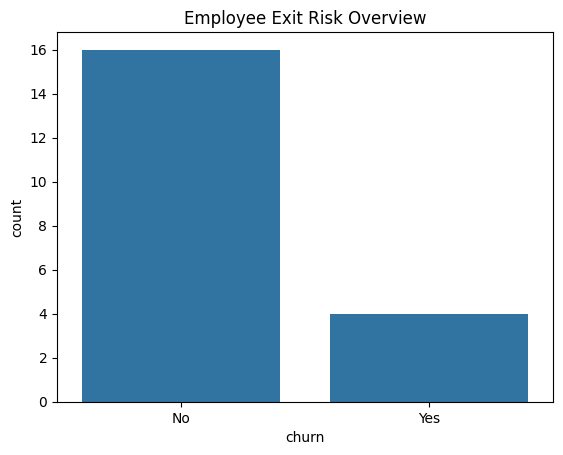

In [ ]:
 # Churn → Who will leave company
 # This shows how many employees are leaving vs staying
 #Target, To check if the data is balanced or not
 sns.countplot(x="churn", data=df)
plt.title("Employee Exit Risk Overview")
plt.show()

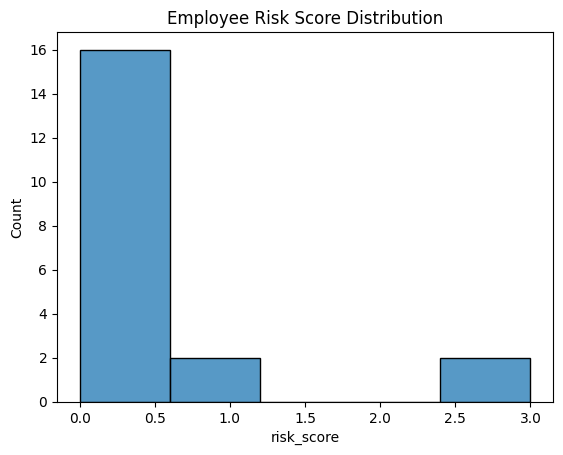

In [ ]:
# Risk Idea - Employees with low performance, low experience, or very high salary may leave
df["risk_score"] = (
    (df["performance_score"] < 3).astype(int)*2 +
    (df["salary"] > df["salary"].quantile(0.9)).astype(int) +
    (df["experience"] < 2).astype(int)
)

sns.histplot(df["risk_score"], bins=5)
plt.title("Employee Risk Score Distribution")
plt.show()